### COMP 3610 Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime

In [2]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error

In [4]:
from xgboost import XGBRegressor

In [72]:
df = pd.read_csv("synthetic.csv")

Evaluating the synthetic data

In [73]:
import matplotlib.pyplot as plt 
import seaborn as sns

Comparing the Distribution of Particular Features

## Exploratory Visualisations
#### Trend in Power Generation over Time

In [ ]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='Date', y='Power Generated', data=df, marker='o')
plt.title('Power Generation Over Time')
plt.xlabel('Date')
plt.ylabel('Power Generated')
plt.show()

#### Distribution of Power Generated by Months

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Month', y='Power Generated', data=df, palette = 'crest', hue = 'Month')
plt.title('Power Generation Across Months')
plt.xlabel('Month')
plt.ylabel('Power Generated')
plt.show()

#### Power Versus Temperature/Wind Speed/Humidity

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='Average Temperature (Day)', y='Power Generated', data=df, ax=axes[0])
axes[0].set_title('Power vs Temperature')

sns.scatterplot(x='Average Wind Speed (Day)', y='Power Generated', data=df, ax=axes[1])
axes[1].set_title('Power vs Wind Speed')

sns.scatterplot(x='Relative Humidity', y='Power Generated', data=df, ax=axes[2])
axes[2].set_title('Power vs Humidity')

#### Important Feature Correlation

In [ ]:
plt.figure(figsize = (16,12))
sns.heatmap(df.corr(), annot = True)
plt.show()

#### Analysing Average Power Generated by Wind Direction

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Average Wind Direction (Day)', y='Power Generated', data=df, palette = 'Spectral', hue = 'Average Wind Direction (Day)', legend = False)
plt.xticks(rotation=0)
plt.title('Average Power Generated by Wind Direction')
plt.xlabel('Wind Direction (Degrees)')
plt.ylabel('Power Generated')
plt.show()

#### Comparing Power Generation during the Day versus at Night

In [ ]:
avg_power_daylight = df.groupby('Is Daylight')['Power Generated'].mean().reset_index()

# Create bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Is Daylight', y='Power Generated', data=avg_power_daylight, palette='coolwarm', hue = 'Is Daylight', legend = False)

plt.xlabel('Is Daylight')
plt.ylabel('Average Power Generated')
plt.title('Average Power Generation: Daylight vs Non-Daylight')
plt.xticks([0, 1], ['No', 'Yes'])  # Ensure proper labels

plt.show()

#### Observing the Relationship between Wind Direction, Wind Speed and Power Generation

In [ ]:
import plotly.express as px

In [ ]:
fig = px.scatter_polar(df, r='Average Wind Speed (Day)', theta='Average Wind Direction (Day)',
                        size='Power Generated', color='Power Generated',
                        title="Wind Direction vs Wind Speed vs Power Generation",
                        color_continuous_scale=px.colors.sequential.Plasma)
fig.show()

#### Comparing Power Generated against Distance to Solar Moon (Midday)

In [ ]:
df_daylight = df[(df['Is Daylight'] == 1)].copy()

df_daylight = df_daylight.sort_values(by='Distance to Solar Noon')

plt.figure(figsize=(10, 5))
sns.lineplot(x='Distance to Solar Noon', y='Power Generated', data=df_daylight, marker='o', color='b')

plt.xlabel('Distance to Solar Noon')
plt.ylabel('Power Generated')
plt.title('Power Generation vs Distance to Solar Noon (Daylight Only)')
plt.grid(True)

plt.show()

#### Average Power Generation by Hour

In [ ]:
avg_power_by_hour = df.groupby("First Hour of Period")["Power Generated"].mean()

In [ ]:
plt.figure(figsize=(8, 5))
avg_power_by_hour.plot(kind="bar", color="skyblue", edgecolor="black")

# Labels and title
plt.xlabel("First Hour of Period")
plt.ylabel("Average Power Generated")
plt.title("Average Power Generation for Each Hour")
plt.xticks(rotation=0)  # Keep labels readable

# Show plot
plt.show()

Since the data is structured and the value to be predicited is continuous, this is a linear regression problem. When deciding between XGBoost and Random Forest as potential models to implement, we decided on XGBoost for the following reasons:
* XGBoost's method of building 'trees' sequentially and correcting errors made by the previous one is highly effective at reducing bias and variance which is essential for predictive accuracy.
* The sequential nature of the training process is negligible since the dataset being used is not exteremely large.
* It offers greater fexibility when tuning parameters of the model, allowing us more room for experimentation and increased performance.
* It is designed to be scaled up for larger datasets.

In [75]:
def timer(start = None):
    if not start:
        start = datetime.now()
        return start
    elif start:
        hour, temp_sec = divmod((datetime.now() - start).total_seconds(), 3600)
        mins, sec = divmod(temp_sec, 60)
        print(f'Time taken: {int(hour)} hours, {int(mins)} minutes and {round(sec,2)} seconds.')

In [80]:
feature_columns = [
   "hour_cos", "hour_sin", "Is Daylight",
    "Distance to Solar Noon", "Average Temperature (Day)", "Average Wind Direction (Day)", 
    "Average Wind Speed (Day)", "Relative Humidity", 
    "Average Wind Speed (Period)", "Average Barometric Pressure (Period)"
]

In [81]:
X = df[feature_columns]
y = df['Power Generated']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [82]:
xgb = XGBRegressor()

In [83]:
xgb.fit(X_train, y_train) # Training xgb model on X_train and y_train
y_predicted = xgb.predict(X_test) #Predicting y_test values based on model and X_test

In [84]:
xgb_mse = mean_squared_error(y_test, y_predicted)
xgb_rsq = r2_score(y_test, y_predicted)
xgb_mae = mean_absolute_error(y_test, y_predicted)

In [85]:
print(f"XGBoost Mean Square Error: {xgb_mse: .4f}\nXGBoost Mean Absolute Error: {xgb_mae: .4f}\nXGBoost R2 Score: {xgb_rsq: .4f}")

XGBoost Mean Square Error:  6398268.7128
XGBoost Mean Absolute Error:  1049.6434
XGBoost R2 Score:  0.9397


In [90]:
xgb_parameters = {'n_estimators': [100, 200, 500, 700],
                  'learning_rate': [0.01, 0.05, 0.1, 0.2],
                  'max_depth': [3, 5, 7, 9]}

In [91]:
xgb_grid = GridSearchCV(xgb, param_grid = xgb_parameters, cv = 4, scoring = 'neg_mean_absolute_error')

In [92]:
start = timer(None)
xgb_grid.fit(X_train, y_train)
timer(start)

Time taken: 0 hours, 1 minutes and 20.11 seconds.


In [93]:
print(xgb_grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 700}


In [96]:
xgb_fine_parameters = {'n_estimators': [600, 700, 800],
                  'learning_rate': [0.025, 0.05, 0.075],
                  'max_depth': [6,7,8]}

In [97]:
xgb_grid = GridSearchCV(xgb, param_grid = xgb_fine_parameters, cv = 3, scoring = 'neg_mean_absolute_error')

In [98]:
start = timer(None)
xgb_grid.fit(X_train, y_train)
timer(start)

Time taken: 0 hours, 0 minutes and 49.96 seconds.


In [99]:
print(xgb_grid.best_params_)

{'learning_rate': 0.075, 'max_depth': 7, 'n_estimators': 800}


In [100]:
xgb_final = XGBRegressor(learning_rate = 0.075, max_depth = 7, n_estimators = 800)

In [101]:
xgb_final.fit(X_train, y_train) # Training xgb model on X_train and y_train
y_predicted_final = xgb_final.predict(X_test) #Predicting y_test values based on model and X_test

In [102]:
xgb_mse = mean_squared_error(y_test, y_predicted_final)
xgb_rsq = r2_score(y_test, y_predicted_final)
xgb_mae = mean_absolute_error(y_test, y_predicted_final)

In [103]:
print(f"XGBoost Mean Square Error: {xgb_mse: .4f}\nXGBoost Mean Absolute Error: {xgb_mae: .4f}\nXGBoost R2 Score: {xgb_rsq: .4f}")

XGBoost Mean Square Error:  6820982.4035
XGBoost Mean Absolute Error:  1031.5403
XGBoost R2 Score:  0.9357


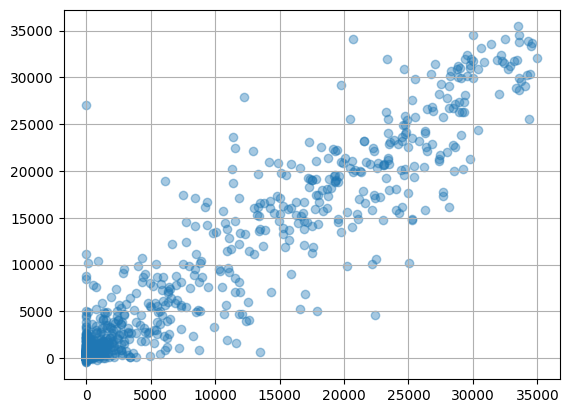

In [65]:
plt.scatter(y_test, y_predicted_final, alpha =0.4)
plt.grid(True)
plt.show()

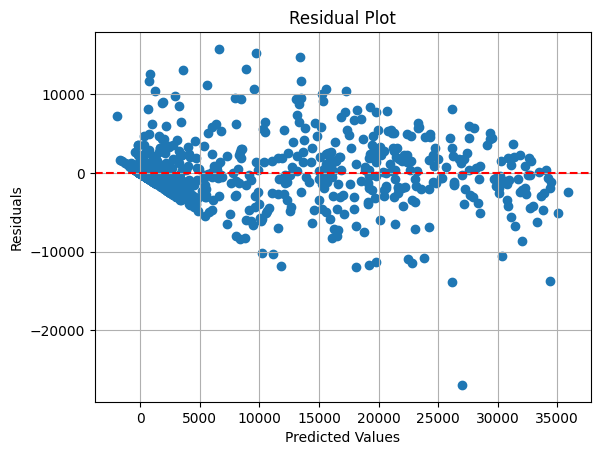

In [70]:
residuals = y_test - y_predicted
plt.scatter(y_predicted, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [65]:
xgb_final.save_model('xgb_model.json')  

## API

In [ ]:
!pip install fastapi uvicorn nest_asyncio pydantic

In [ ]:
from fastapi import FastAPI, Form, HTTPException
from fastapi.responses import HTMLResponse
from fastapi import Request
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import uvicorn
import nest_asyncio
import logging

nest_asyncio.apply()

# Set up FastAPI app
app = FastAPI()

# Set up logging
logging.basicConfig(level=logging.DEBUG)

# Initialize the model variable
xgb_final = None

@app.on_event("startup")
async def load_model():
    global xgb_final
    try:
        xgb_final = xgb.Booster()
        xgb_final.load_model('xgb_model.json')  # Replace with your actual model path
        logging.info("Model loaded successfully.")
    except Exception as e:
        logging.error(f"Error loading model: {e}")
        raise HTTPException(status_code=500, detail="Model could not be loaded.")

# Default values for missing data 
defaults = {
    'first_hour': 12,
    'is_daylight': 1,
    'solar_noon': 0.5,
    'temp_day': 25.0,
    'wind_dir_day': 180.0,
    'wind_speed_day': 5.0,
    'humidity': 60.0,
    'wind_speed_period': 4.0,
    'pressure': 1013.25
}

feature_names = [
    "First Hour of Period",
    "Is Daylight",
    "Distance to Solar Noon",
    "Average Temperature (Day)",
    "Average Wind Direction (Day)",
    "Average Wind Speed (Day)",
    "Relative Humidity",
    "Average Wind Speed (Period)",
    "Average Barometric Pressure (Period)"
]

# Backend Prediction: Process the form data and predict power output
@app.post("/predict-ui", response_class=HTMLResponse)
async def predict_ui(
    request: Request,
    first_hour: str = Form(None),
    is_daylight: str = Form(None),
    solar_noon: str = Form(None),
    temp_day: str = Form(None),
    wind_dir_day: str = Form(None),
    wind_speed_day: str = Form(None),
    humidity: str = Form(None),
    wind_speed_period: str = Form(None),
    pressure: str = Form(None)
):
    try:
        # Convert the form inputs to float and fill missing values with defaults
        filled_inputs = [
            float(first_hour) if first_hour not in [None, ""] else defaults['first_hour'],
            float(is_daylight) if is_daylight not in [None, ""] else defaults['is_daylight'],
            float(solar_noon) if solar_noon not in [None, ""] else defaults['solar_noon'],
            float(temp_day) if temp_day not in [None, ""] else defaults['temp_day'],
            float(wind_dir_day) if wind_dir_day not in [None, ""] else defaults['wind_dir_day'],
            float(wind_speed_day) if wind_speed_day not in [None, ""] else defaults['wind_speed_day'],
            float(humidity) if humidity not in [None, ""] else defaults['humidity'],
            float(wind_speed_period) if wind_speed_period not in [None, ""] else defaults['wind_speed_period'],
            float(pressure) if pressure not in [None, ""] else defaults['pressure']
        ]
        logging.debug(f"Filled Inputs: {filled_inputs}")
    except ValueError as e:
        logging.error(f"Error parsing inputs: {e}")
        return HTMLResponse(content="Invalid input! Please ensure all inputs are numbers.", status_code=400)

    input_array = np.array([filled_inputs])

    logging.debug(f"Input Array Shape: {input_array.shape}")

    try:
        dmatrix_input = xgb.DMatrix(input_array, feature_names=feature_names)
        prediction = xgb_final.predict(dmatrix_input)[0]
        logging.info(f"Prediction: {prediction}")
    except Exception as e:
        logging.error(f"Error during prediction: {e}")
        return HTMLResponse(content=f"Error during prediction: {e}", status_code=500)

    try:
        xgb_mse = mean_squared_error([filled_inputs], [prediction])  # MSE
        xgb_rsq = r2_score([filled_inputs], [prediction])  # R²
        xgb_mae = mean_absolute_error([filled_inputs], [prediction])  # MAE
        logging.debug(f"Metrics: MSE={xgb_mse}, R²={xgb_rsq}, MAE={xgb_mae}")
    except Exception as e:
        logging.error(f"Error calculating metrics: {e}")
        return HTMLResponse(content=f"Error calculating metrics: {e}", status_code=500)

    # HTML response displaying results
    return HTMLResponse(
        content=f"""
        <html>
            <head>
                <title>Prediction Result</title>
                <style>
                    body {{
                        font-family: Arial, sans-serif;
                        background-color: #e5f5e0;
                        color: #333;
                        margin: 0;
                        padding: 0;
                        display: flex;
                        justify-content: center;
                        align-items: center;
                        height: 100vh;
                    }}
                    .container {{
                        background-color: #ffffff;
                        padding: 20px;
                        border-radius: 8px;
                        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
                        text-align: center;
                        max-width: 600px;
                        width: 100%;
                    }}
                    h1 {{
                        color: #4CAF50;
                    }}
                    p {{
                        font-size: 1.2rem;
                        margin: 15px 0;
                    }}
                    .button {{
                        background-color: #4CAF50;
                        color: white;
                        border: none;
                        padding: 10px 20px;
                        font-size: 16px;
                        cursor: pointer;
                        border-radius: 4px;
                    }}
                    .button:hover {{
                        background-color: #45a049;
                    }}
                    a {{
                        text-decoration: none;
                        color: #4CAF50;
                        font-size: 16px;
                    }}
                    a:hover {{
                        text-decoration: underline;
                    }}
                </style>
            </head>
            <body>
                <div class="container">
                    <h1>Power Prediction</h1>
                    <p><b>Predicted Power Output:</b> {round(float(prediction), 2)}</p>
                    <p><b>Mean Squared Error (MSE):</b> {round(xgb_mse, 2)}</p>
                    <p><b>R-Squared (R²):</b> {round(xgb_rsq, 2)}</p>
                    <p><b>Mean Absolute Error (MAE):</b> {round(xgb_mae, 2)}</p>
                    <br>
                    <a href="/">Go Back to Input Form</a>
                </div>
            </body>
        </html>
        """
    )

# Route to display the input form
@app.get("/", response_class=HTMLResponse)
async def form(request: Request):
    return HTMLResponse(
        content=f"""
        <html>
            <head>
                <title>Power Prediction</title>
                <style>
                    body {{
                        font-family: Arial, sans-serif;
                        background-color: #e5f5e0;
                        color: #333;
                        margin: 0;
                        padding: 0;
                        display: flex;
                        justify-content: center;
                        align-items: center;
                        height: 100vh;
                    }}
                    .container {{
                        background-color: #ffffff;
                        padding: 20px;
                        border-radius: 8px;
                        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
                        text-align: center;
                        max-width: 500px;
                        width: 100%;
                    }}
                    h1 {{
                        color: #4CAF50;
                    }}
                    form {{
                        display: flex;
                        flex-direction: column;
                        align-items: center;
                    }}
                    label {{
                        font-size: 16px;
                        margin: 10px 0;
                    }}
                    input[type="number"] {{
                        padding: 8px;
                        font-size: 16px;
                        margin: 5px;
                        width: 80%;
                        max-width: 300px;
                        border-radius: 4px;
                        border: 1px solid #ccc;
                    }}
                    input[type="submit"] {{
                        background-color: #4CAF50;
                        color: white;
                        border: none;
                        padding: 12px 24px;
                        font-size: 18px;
                        cursor: pointer;
                        border-radius: 4px;
                        width: 80%;
                        max-width: 300px;
                    }}
                    input[type="submit"]:hover {{
                        background-color: #45a049;
                    }}
                </style>
            </head>
            <body>
                <div class="container">
                    <h1>Power Prediction Based on Weather Conditions</h1>
                    <form action="/predict-ui" method="post">
                        <label for="first_hour">First Hour of Period:</label>
                        <input type="number" name="first_hour" step="any" placeholder="Enter First Hour"><br>

                        <label for="is_daylight">Is Daylight (1 or 0):</label>
                        <input type="number" name="is_daylight" step="any" placeholder="Enter 1 or 0"><br>

                        <label for="solar_noon">Distance to Solar Noon:</label>
                        <input type="number" name="solar_noon" step="any" placeholder="Enter Distance to Solar Noon"><br>

                        <label for="temp_day">Average Temperature (Day):</label>
                        <input type="number" name="temp_day" step="any" placeholder="Enter Temperature"><br>

                        <label for="wind_dir_day">Average Wind Direction (Day):</label>
                        <input type="number" name="wind_dir_day" step="any" placeholder="Enter Wind Direction"><br>

                        <label for="wind_speed_day">Average Wind Speed (Day):</label>
                        <input type="number" name="wind_speed_day" step="any" placeholder="Enter Wind Speed"><br>

                        <label for="humidity">Relative Humidity:</label>
                        <input type="number" name="humidity" step="any" placeholder="Enter Humidity"><br>

                        <label for="wind_speed_period">Average Wind Speed (Period):</label>
                        <input type="number" name="wind_speed_period" step="any" placeholder="Enter Wind Speed Period"><br>

                        <label for="pressure">Average Barometric Pressure (Period):</label>
                        <input type="number" name="pressure" step="any" placeholder="Enter Pressure"><br>

                        <input type="submit" value="Predict Power">
                    </form>
                </div>
            </body>
        </html>
        """
    )

if __name__ == "__main__":
    uvicorn.run(app, host="127.0.0.1", port=8000)


### Random Forest

In [106]:
rfc = RandomForestRegressor()
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

In [107]:
rfc_mae = mean_absolute_error(y_test, y_pred_rfc)
rfc_rs2 = r2_score(y_test, y_pred_rfc)
rfc_mse = mean_squared_error(y_test, y_pred_rfc)

In [108]:
print(f"Random Forest Mean Square Error: {rfc_mse: .4f}\nRandom Forest Mean Absolute Error: {rfc_mae: .4f}\nRandom Forest R2 Score: {rfc_rs2: .4f}")

Random Forest Mean Square Error:  6288831.7430
Random Forest Mean Absolute Error:  1003.0537
Random Forest R2 Score:  0.9407


In [109]:
rfr_parameters = {'n_estimators': [300, 500, 700],#, 700],
                  'min_samples_split': [3,5, 7],#,7],
                  'min_samples_leaf': [3,5,7],#,7],
                  'max_depth': [10, 18, 25],#, 25],
                  'max_features': ['sqrt', 'log2']}#, None]}

In [110]:
rfr_grid = GridSearchCV(rfc, param_grid = rfr_parameters, cv = 4, scoring = 'neg_mean_absolute_error', n_jobs =1)

In [ ]:
start = timer(None)
rfr_grid.fit(X_train, y_train)
timer(start)

In [26]:
print(rfr_grid.best_params_)

{'max_depth': 18, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 700}


In [30]:
rfr_parameters_final = {'n_estimators': [600, 700, 800],
                  'min_samples_split': [4,5,6],
                  'min_samples_leaf': [2,3,4],
                  'max_depth': [16,18,20],
                  'max_features': ['log2', None]}

In [31]:
rfr_grid_final = GridSearchCV(rfc, param_grid = rfr_parameters_final, cv = 4, scoring = 'neg_mean_absolute_error', n_jobs =1)

In [35]:
start = timer(None)
rfr_grid_final.fit(X_train, y_train)
timer(start)

Time taken: 0.0 hours, 51.0 minutes and 46.09 seconds.


In [36]:
print(rfr_grid_final.best_params_)

{'max_depth': 18, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 600}


In [37]:
rfr_final = RandomForestRegressor(max_depth =18, max_features = None, min_samples_leaf =2, min_samples_split=4, n_estimators =600)

In [38]:
rfr_final.fit(X_train, y_train)

RandomForestRegressor(max_depth=18, max_features=None, min_samples_leaf=2,
                      min_samples_split=4, n_estimators=600)

In [39]:
y_pred_final = rfr_final.predict(X_test)

In [40]:
rfc_mae = mean_absolute_error(y_test, y_pred_rfc_final)
rfc_rs2 = r2_score(y_test, y_pred_rfc_final)
rfc_mse = mean_squared_error(y_test, y_pred_rfc_final)

In [41]:
print(f"Random Forest Mean Square Error: {rfc_mse: .4f}\nRandom Forest Mean Absolute Error: {rfc_mae: .4f}\nRandom Forest R2 Score: {rfc_rs2: .4f}")

Random Forest Mean Square Error:  10175393.2969
Random Forest Mean Absolute Error:  1786.2124
Random Forest R2 Score:  0.9005


# CNN-LSTM
## Reshaping the time series
Reshaping the time series data so that the CNN can learn from sequences of past values to predict the next output.

## Selection of number of time steps
This is a very important hyperparameter as the model's performance depends on how far back it looks in times.
The data for this project considers every three hours of a day. I will hypertune between 3 values of time steps:
1) 4 time steps - Goes 0.5 days in the past
2) 8 time steps - Goes 1.0 days in the past
3) 12 time steps - Goes 1.5 days in the past 

In [112]:
time_steps = 8

X_sequences = []
y_sequences = []

for i in range(len(X) - time_steps):
    X_sequences.append(X[i:i + time_steps])
    y_sequences.append(y[i + time_steps])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

num_features = X_sequences.shape[2]

# Step 2 Building the model

In [ ]:
# Creating empty neural networ model using Kera's Sequential API
model = Sequential()

## CNN Section
Using a 1d Convolutional Layer.
1) filters = 64: this means there are 64 different pattern detectors.
2) kernel = 2:  each filter sees 2 time steps at a time
3) activation='relu' :Applies non-linear ReLU to introduce flexibility
4) input_shape: (Time step size and Number of features)

In [ ]:
model.add(Input(shape=(time_steps, num_features)))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

### Dropout Regularization:
Dropping 20% of outputs to 0 during training to help prevent overfitting by making the model less reliant on a single neuron

In [ ]:
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

In [71]:
## LSTM Section

Adding the long short-term memory layer with the following parameters:
1) 50 LTSM neurons with memory cells
2) ReLU for non-linearity

In [ ]:
model.add(LSTM(50, activation='relu'))
model.add(Dropout(0.2))

Final layer — a fully connected (Dense) layer with 1 neuron
>Outputs the power generated

In [ ]:
model.add(Dense(1))

## Compiling the Model

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## Model Summary

In [ ]:
model.summary()

# Step 3: Training the model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_sequences, y_sequences, test_size=0.2, random_state=42)

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))